# Inférence — CNN sur le dataset GTSRB Test

Ce notebook teste le modèle `cnn_gtsrb.pth` sur le dataset officiel **GTSRB_Final_Test_Images.zip**.

On utilise **40 % du dataset test** pour l'inférence.


## 1. Import des librairies

In [21]:
import os
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

from torchvision import transforms
import matplotlib.pyplot as plt

print("Version de PyTorch :", torch.__version__)

Version de PyTorch : 2.10.0+cpu


## 2. Télécharger le dataset test officiel

In [22]:
!rm -rf GTSRB
!rm -f GTSRB_Final_Test_Images.zip*
!rm -f GTSRB_Final_Test_GT.zip*

!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
!wget https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip

!unzip -q -o GTSRB_Final_Test_Images.zip
!unzip -q -o GTSRB_Final_Test_GT.zip

--2026-05-14 13:56:02--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 88978620 (85M) [application/zip]
Saving to: ‘GTSRB_Final_Test_Images.zip’

GTSRB_Final_Test_Im 100%[===================>]  84.86M  15.4MB/s    in 5.8s    

2026-05-14 13:56:08 (14.7 MB/s) - ‘GTSRB_Final_Test_Images.zip’ saved [88978620/88978620]

--2026-05-14 13:56:08--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99620 (97K) [application/zip]
Saving to: ‘GTSRB_Final_Test_GT.zip’

GTSRB_Final_Test_GT 100%[===================>]  97.29K   383KB/s    in 0.3s    

## 3. Définir les chemins

In [23]:
test_images_dir = "/content/GTSRB/Final_Test/Images"
csv_path = "/content/GT-final_test.csv"

print("Dossier courant :", os.getcwd())
print("Images test existe :", os.path.exists(test_images_dir))
print("CSV existe :", os.path.exists(csv_path))

if os.path.exists(test_images_dir):
    print("Exemples d'images :", os.listdir(test_images_dir)[:5])

Dossier courant : /content
Images test existe : True
CSV existe : True
Exemples d'images : ['10020.ppm', '05443.ppm', '03554.ppm', '07138.ppm', '01589.ppm']


## 4. Prétraitement des images

In [24]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.3403, 0.3121, 0.3214],
        std=[0.2724, 0.2608, 0.2669]
    )
])

## 5. Dataset personnalisé pour le dataset test

In [25]:
class GTSRBTestDataset(Dataset):
    def __init__(self, images_dir, csv_path, transform=None):
        self.images_dir = images_dir
        self.data = pd.read_csv(csv_path, sep=";")
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        if torch.is_tensor(idx):
            idx = idx.item()

        idx = int(idx)

        row = self.data.iloc[idx]

        image_path = os.path.join(self.images_dir, row["Filename"])
        image = Image.open(image_path).convert("RGB")

        label = int(row["ClassId"])

        if self.transform:
            image = self.transform(image)

        return image, label

## 6. Charger le dataset test

In [26]:
full_test_dataset = GTSRBTestDataset(
    images_dir=test_images_dir,
    csv_path=csv_path,
    transform=transform
)

print("Nombre total d'images test :", len(full_test_dataset))

Nombre total d'images test : 12630


## 7. Prendre 40 % du dataset test

In [27]:
test_size = int(0.40 * len(full_test_dataset))

indices = torch.randperm(
    len(full_test_dataset),
    generator=torch.Generator().manual_seed(42)
)[:test_size].tolist()

test_subset = Subset(full_test_dataset, indices)

test_loader = DataLoader(
    test_subset,
    batch_size=64,
    shuffle=False
)

print("Nombre d'images utilisées pour l'inférence :", len(test_subset))
print("Nombre de batchs :", len(test_loader))

Nombre d'images utilisées pour l'inférence : 5052
Nombre de batchs : 79


## 8. Définir l'architecture CNN

In [28]:
class CNN_model(nn.Module):
    def __init__(self, num_classes=43):
        super(CNN_model, self).__init__()

        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(128 * 8 * 8, 256)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # 64 -> 32
        x = self.pool(F.relu(self.conv2(x)))  # 32 -> 16
        x = self.pool(F.relu(self.conv3(x)))  # 16 -> 8

        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

## 9. Charger le modèle sauvegardé

Avant cette étape, importer `cnn_gtsrb.pth` dans Colab.

Le modèle doit être ici :

```text
/content/cnn_gtsrb.pth
```


In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", device)
model_path = "cnn_gtsrb.pth"
model = CNN_model(num_classes=43).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("Modèle chargé avec succès.")

Device utilisé : cpu
Modèle chargé avec succès.


## 10. Évaluation sur 40 % du dataset test

In [30]:
correct = 0
total = 0

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predictions = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
print(f"Accuracy sur 40 % du dataset test : {accuracy:.4f}")

Accuracy sur 40 % du dataset test : 0.9551


## 11. Fonction de dénormalisation

In [31]:
def denormalize(img):
    mean = torch.tensor([0.3403, 0.3121, 0.3214]).view(3, 1, 1)
    std = torch.tensor([0.2724, 0.2608, 0.2669]).view(3, 1, 1)
    return img * std + mean

## 12. Afficher quelques prédictions

<Figure size 1200x600 with 0 Axes>

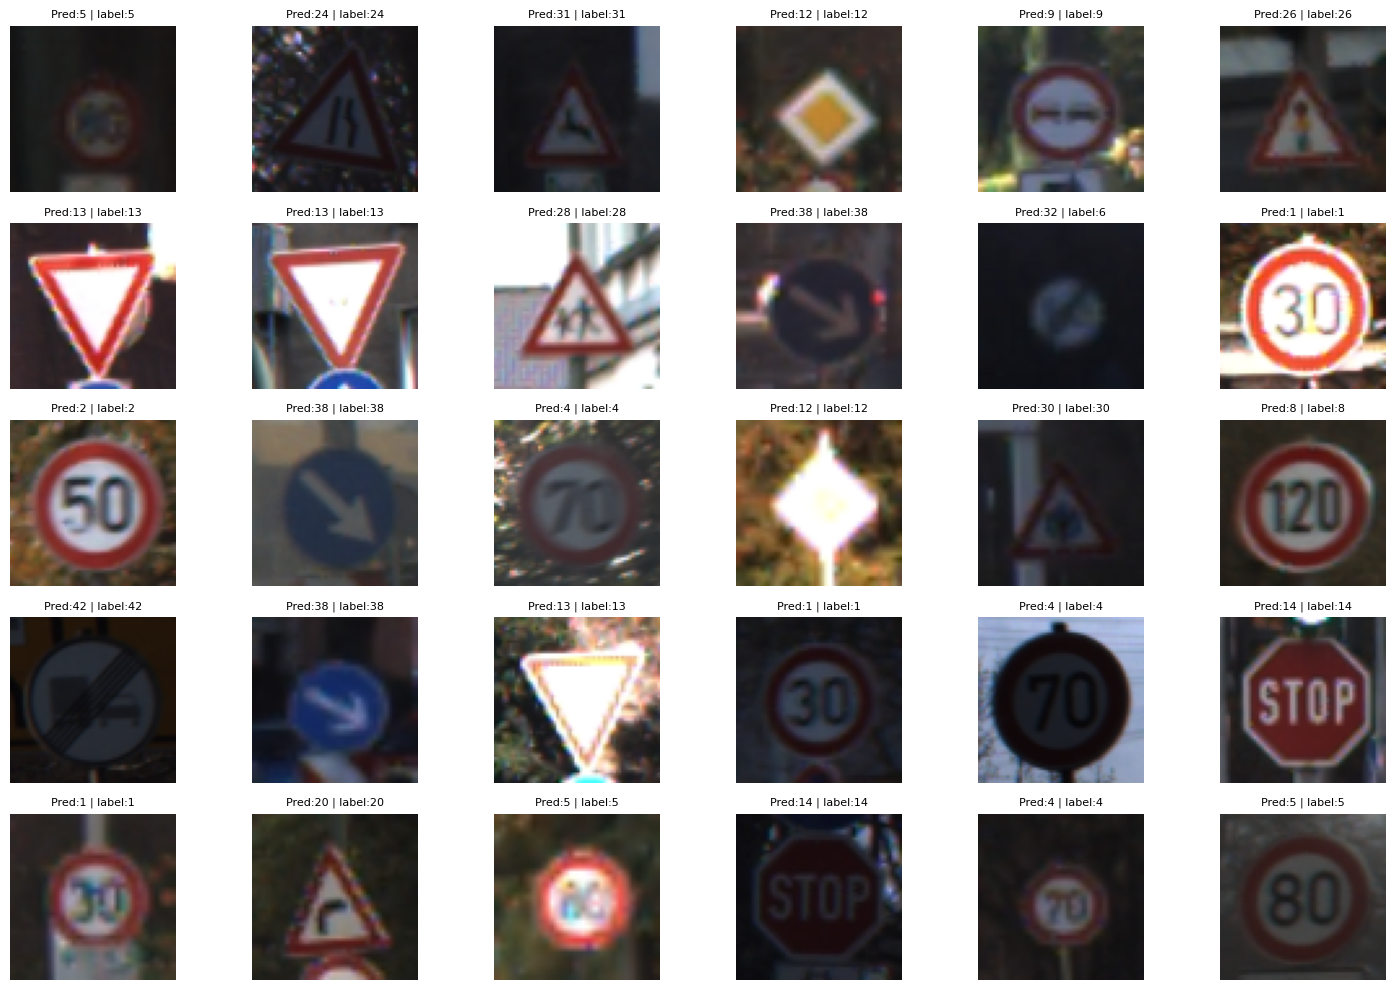

<Figure size 640x480 with 0 Axes>

In [32]:
images, labels = next(iter(test_loader))

images_device = images.to(device)

with torch.no_grad():
    outputs = model(images_device)
    _, predictions = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))

n = 30
cols = 6
rows = (n + cols - 1) // cols

plt.figure(figsize=(15, 10))

for i in range(n):
    img = denormalize(images[i])
    img = img.permute(1, 2, 0)
    img = torch.clamp(img, 0, 1)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Pred:{predictions[i].item()} | label:{labels[i].item()}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

## 13. Analyse des erreurs de prédiction

Cette section analyse en détail les erreurs survenues lors de l'inférence :

- Classes les plus confondues
- Visualisation des images mal classifiées

In [33]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Noms des classes GTSRB (43 classes)
CLASS_NAMES = [
    "Limite 20", "Limite 30", "Limite 50", "Limite 60", "Limite 70",
    "Limite 80", "Fin 80", "Limite 100", "Limite 120", "Dépassement interdit",
    "Dépassement PL interdit", "Priorité carrefour", "Route prioritaire", "Cédez le passage", "Stop",
    "Circulation interdite", "PL interdit", "Entrée interdite", "Danger", "Virage gauche",
    "Virage droit", "Succession de virages", "Dos d'âne", "Glissière", "Route rétrécie droite",
    "Travaux", "Feux tricolores", "Piétons", "Enfants", "Cyclistes",
    "Verglas", "Animaux", "Danger divers", "Fin dépassement interdit", "Fin dépassement PL",
    "Priorité à droite", "Sens unique", "Impasse", "Voie directe", "Voie gauche obligatoire",
    "Voie droite obligatoire", "Rond-point", "Fin des interdictions"
]

all_labels_np = np.array(all_labels)
all_predictions_np = np.array(all_predictions)

# Indices des erreurs
error_mask = all_labels_np != all_predictions_np
error_indices = np.where(error_mask)[0]

total_errors = error_mask.sum()
total_samples = len(all_labels_np)
error_rate = total_errors / total_samples

print(f"Total images évaluées : {total_samples}")
print(f"Erreurs totales       : {total_errors}")
print(f"Taux d'erreur         : {error_rate:.4f} ({error_rate*100:.2f}%)")
print(f"Accuracy              : {1 - error_rate:.4f} ({(1-error_rate)*100:.2f}%)")


Total images évaluées : 5052
Erreurs totales       : 227
Taux d'erreur         : 0.0449 (4.49%)
Accuracy              : 0.9551 (95.51%)


In [35]:
# --- Top 15 des paires de classes les plus confondues ---
import pandas as pd


cm = confusion_matrix(all_labels_np, all_predictions_np)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

confusion_pairs = []
for true_cls in range(43):
    for pred_cls in range(43):
        if true_cls != pred_cls and cm[true_cls, pred_cls] > 0:
            confusion_pairs.append({
                "Vraie classe": f"{true_cls} — {CLASS_NAMES[true_cls]}",
                "Prédite comme": f"{pred_cls} — {CLASS_NAMES[pred_cls]}",
                "Nb erreurs": cm[true_cls, pred_cls],
                "Taux confusion": f"{cm_normalized[true_cls, pred_cls]*100:.1f}%"
            })

df_confusion = pd.DataFrame(confusion_pairs).sort_values("Nb erreurs", ascending=False)
print("=== Top 15 des confusions les plus fréquentes ===")
print(df_confusion.head(15).to_string(index=False))


=== Top 15 des confusions les plus fréquentes ===
            Vraie classe           Prédite comme  Nb erreurs Taux confusion
           3 — Limite 60           5 — Limite 80          19           9.7%
        36 — Sens unique       38 — Voie directe          10          21.7%
             18 — Danger            27 — Piétons           9           5.5%
            30 — Verglas 11 — Priorité carrefour           9          15.5%
   17 — Entrée interdite   13 — Cédez le passage           7           5.5%
          7 — Limite 100          8 — Limite 120           6           3.0%
           0 — Limite 20           1 — Limite 30           6          27.3%
            25 — Travaux 11 — Priorité carrefour           5           2.7%
             18 — Danger           1 — Limite 30           5           3.0%
          8 — Limite 120           5 — Limite 80           5           2.7%
9 — Dépassement interdit           3 — Limite 60           5           2.7%
            30 — Verglas          29 —

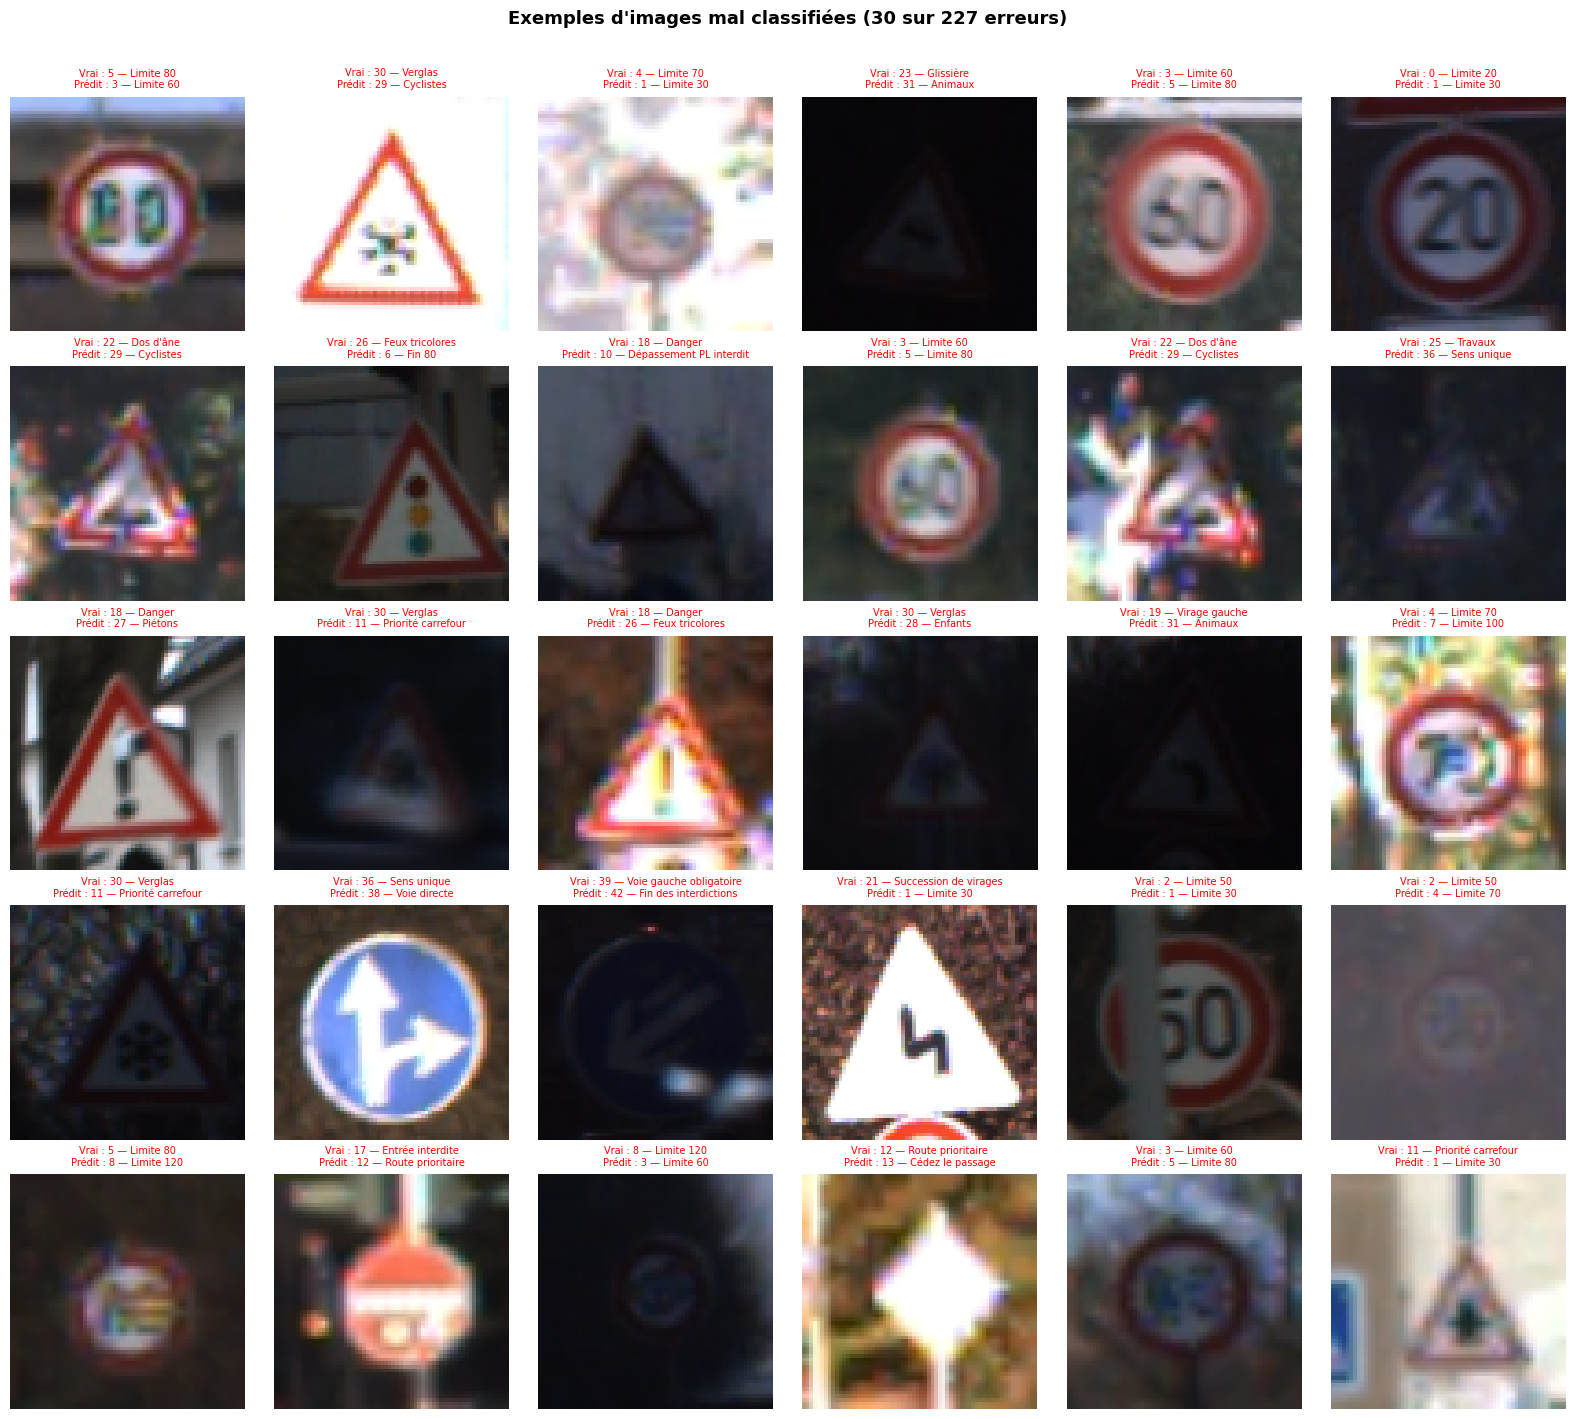

In [ ]:
image_size = 64
# --- Visualisation des images mal classifiées ---
# On récupère les images + labels depuis le subset complet

# Reconstruire un loader qui conserve l'ordre des indices
ordered_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

all_images_list = []
model.eval()
with torch.no_grad():
    for imgs, lbls in ordered_loader:
        all_images_list.append(imgs)

all_images_tensor = torch.cat(all_images_list, dim=0)  # (N, C, H, W)

# Sélectionner jusqu'à 30 erreurs aléatoires
n_show = min(30, len(error_indices))
sample_indices = np.random.choice(error_indices, n_show, replace=False)

cols = 6
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 2.8))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img = denormalize(all_images_tensor[idx])
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()

    true_cls = all_labels_np[idx]
    pred_cls = all_predictions_np[idx]

    axes[i].imshow(img)
    axes[i].set_title(
        f"Vrai : {true_cls} — {CLASS_NAMES[true_cls]}\n"
        f"Prédit : {pred_cls} — {CLASS_NAMES[pred_cls]}",
        fontsize=7, color='red'
    )
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Exemples d'images mal classifiées ({n_show} sur {total_errors} erreurs)",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


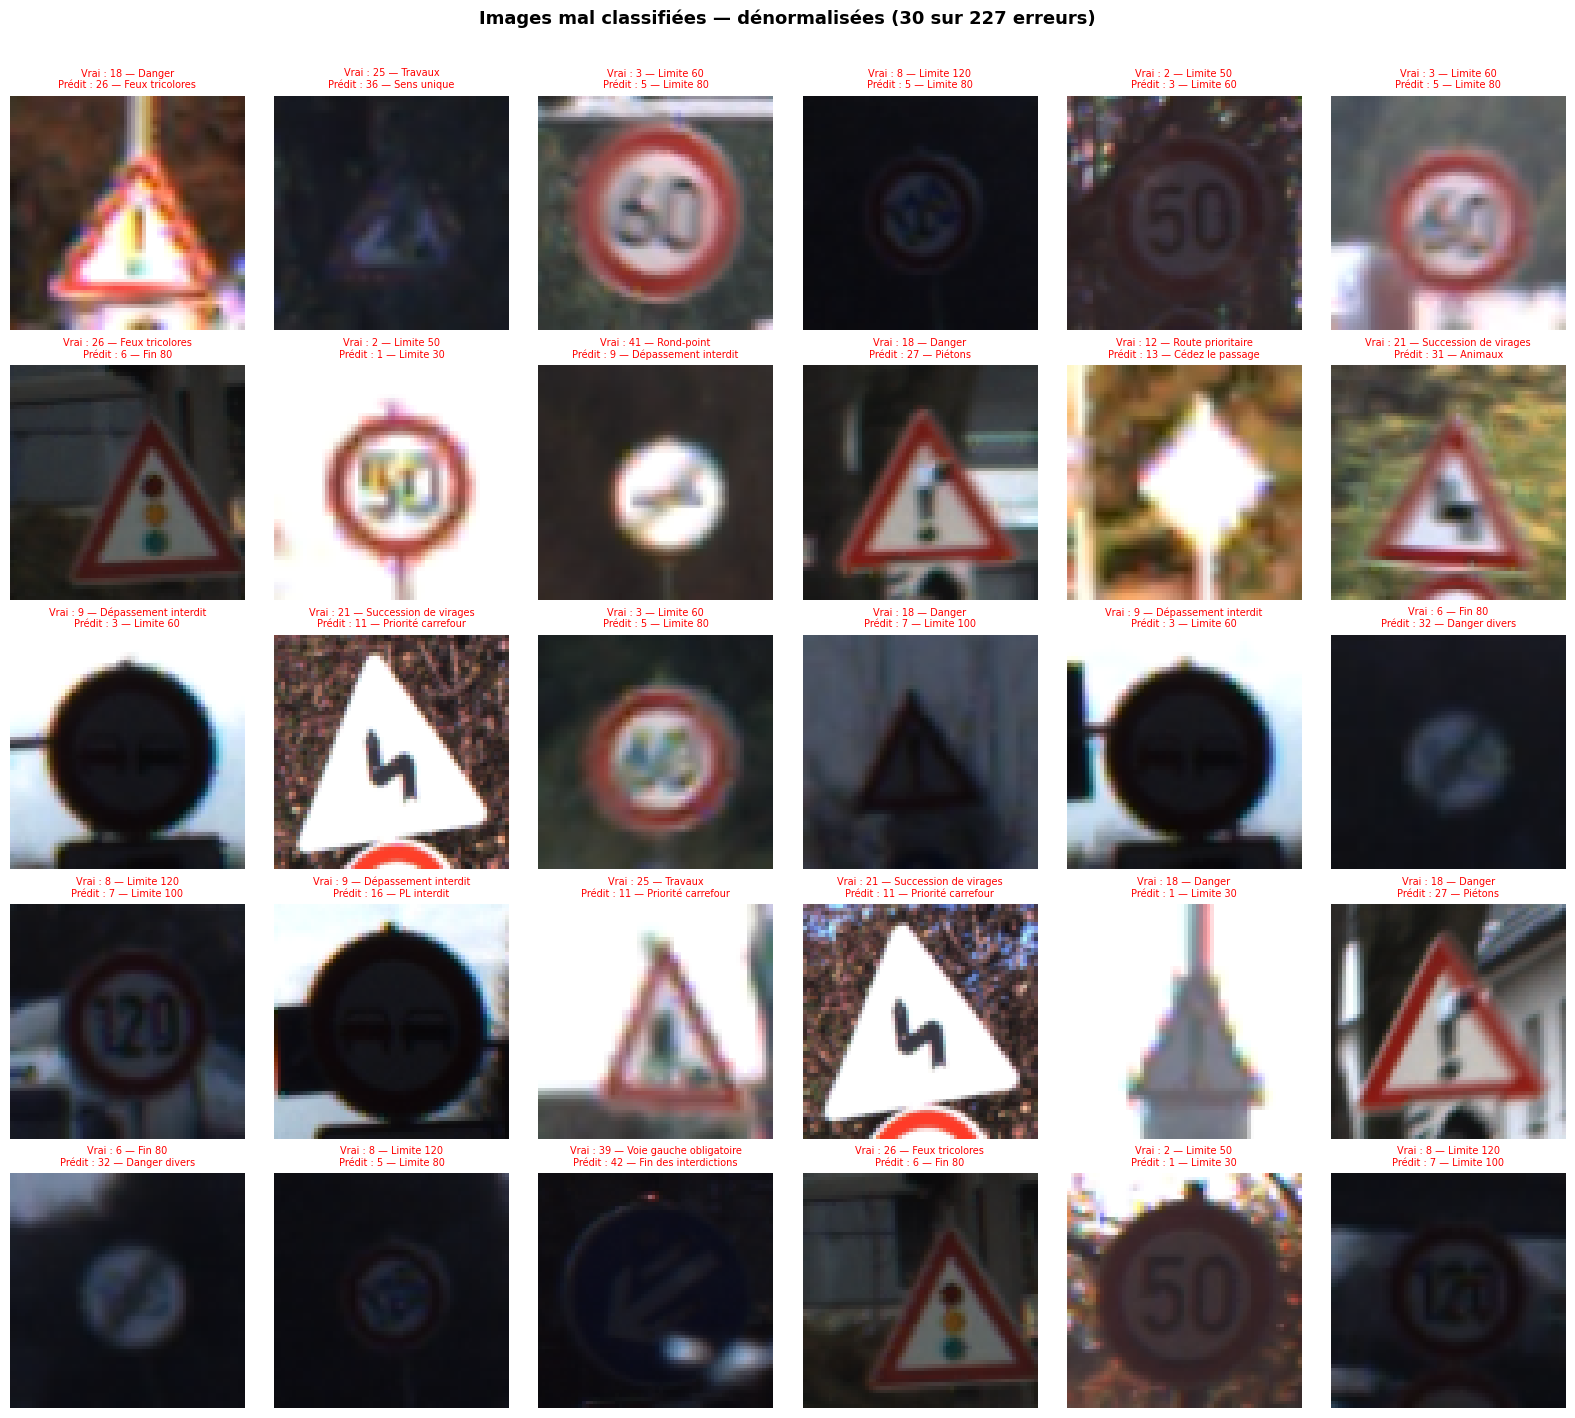

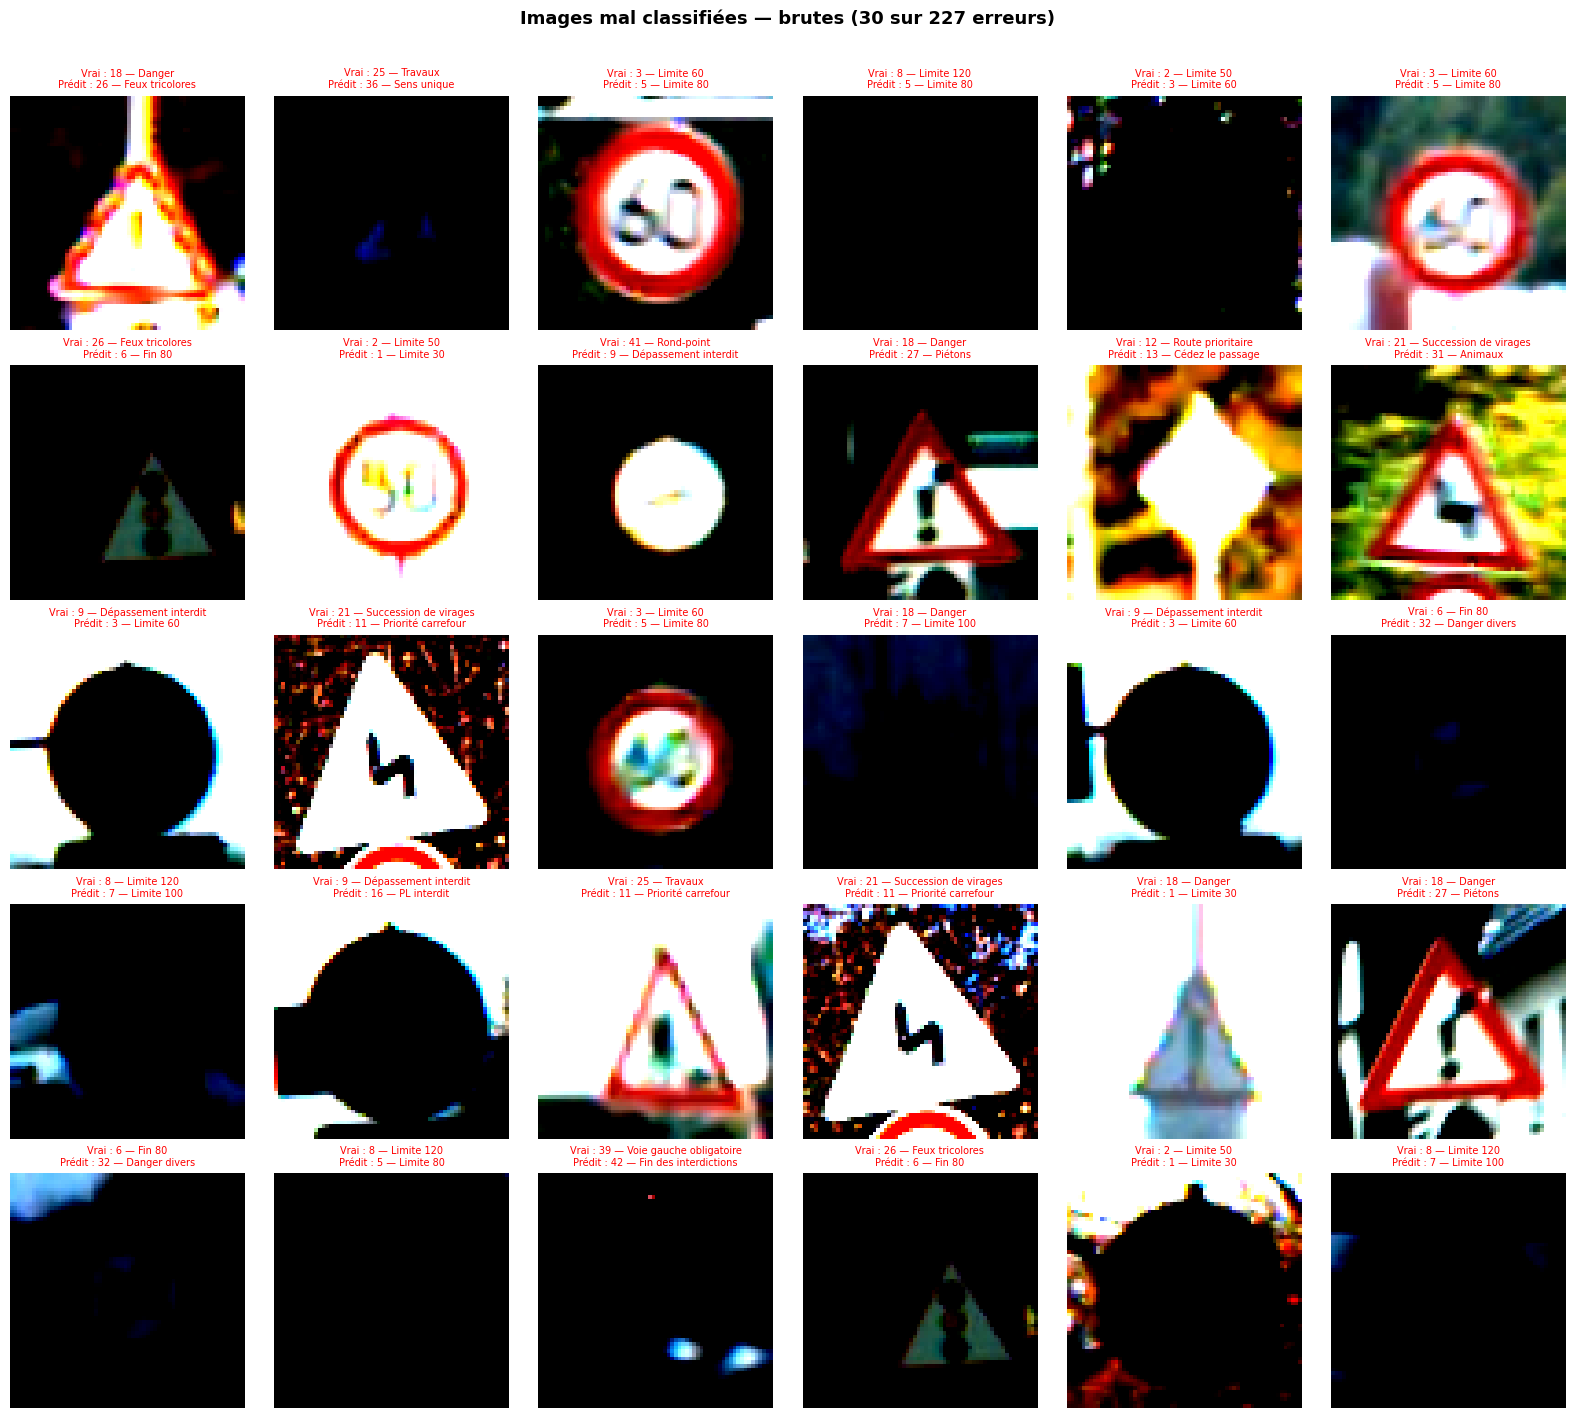

In [41]:
image_size = 64

# Reconstruire un loader ordonné
ordered_loader = DataLoader(test_subset, batch_size=64, shuffle=False)

all_images_list = []
model.eval()
with torch.no_grad():
    for imgs, lbls in ordered_loader:
        all_images_list.append(imgs)

all_images_tensor = torch.cat(all_images_list, dim=0)  # (N, C, H, W)

# Sélectionner jusqu'à 30 erreurs aléatoires
n_show = min(30, len(error_indices))
sample_indices = np.random.choice(error_indices, n_show, replace=False)

cols = 6
rows = (n_show + cols - 1) // cols


# --- Figure 1 : images dénormalisées ---
fig1, axes1 = plt.subplots(rows, cols, figsize=(16, rows * 2.8))
axes1 = axes1.flatten()

for i, idx in enumerate(sample_indices):
    img = denormalize(all_images_tensor[idx])
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()

    true_cls = all_labels_np[idx]
    pred_cls = all_predictions_np[idx]

    axes1[i].imshow(img)
    axes1[i].set_title(
        f"Vrai : {true_cls} — {CLASS_NAMES[true_cls]}\n"
        f"Prédit : {pred_cls} — {CLASS_NAMES[pred_cls]}",
        fontsize=7, color='red'
    )
    axes1[i].axis("off")

for j in range(i + 1, len(axes1)):
    axes1[j].axis("off")

fig1.suptitle(
    f"Images mal classifiées — dénormalisées ({n_show} sur {total_errors} erreurs)",
    fontsize=13, fontweight='bold', y=1.01
)
fig1.tight_layout()
plt.show()


# --- Figure 2 : images brutes (sans dénormalisation) ---
fig2, axes2 = plt.subplots(rows, cols, figsize=(16, rows * 2.8))
axes2 = axes2.flatten()

for i, idx in enumerate(sample_indices):
    img = all_images_tensor[idx]
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()

    true_cls = all_labels_np[idx]
    pred_cls = all_predictions_np[idx]

    axes2[i].imshow(img)
    axes2[i].set_title(
        f"Vrai : {true_cls} — {CLASS_NAMES[true_cls]}\n"
        f"Prédit : {pred_cls} — {CLASS_NAMES[pred_cls]}",
        fontsize=7, color='red'
    )
    axes2[i].axis("off")

for j in range(i + 1, len(axes2)):
    axes2[j].axis("off")

fig2.suptitle(
    f"Images mal classifiées — brutes ({n_show} sur {total_errors} erreurs)",
    fontsize=13, fontweight='bold', y=1.01
)
fig2.tight_layout()
plt.show()